<a href="https://colab.research.google.com/github/2903-adi/23BIT202_CV_Lab_2026-H10-/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

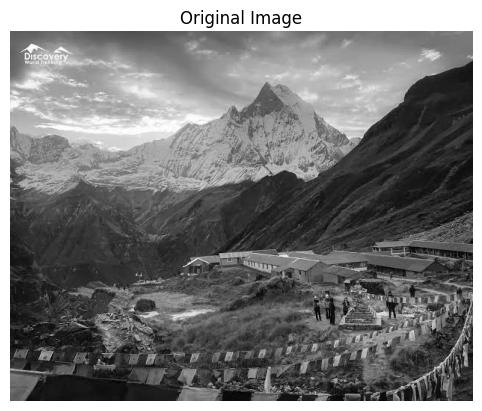

In [3]:
image = cv2.imread("images (3).jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

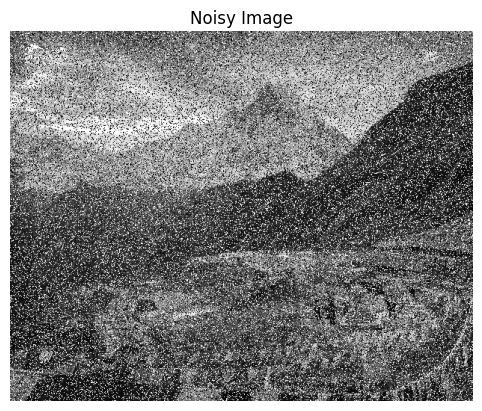

In [5]:
def add_salt_pepper_noise(image, probability=0.1):
    noisy = image.copy()
    random_matrix = np.random.rand(*image.shape)
    noisy[random_matrix < probability / 2] = 0
    noisy[random_matrix > 1 - (probability / 2)] = 255
    return noisy

noisy_image = add_salt_pepper_noise(image, probability=0.3)

plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

In [6]:
def median_filter(img, k=3, s=1):
    h, w = img.shape
    p = k // 2

    pad = np.pad(img, p, mode='reflect')

    oh = (h + 2*p - k) // s + 1
    ow = (w + 2*p - k) // s + 1

    ans = np.zeros((oh, ow), dtype=img.dtype)

    for i in range(oh):
        for j in range(ow):
            r = i * s
            c = j * s

            win = pad[r:r+k, c:c+k]
            ans[i][j] = np.median(win)

    return ans

In [7]:
def mean_filter(img, k=3, s=1):
    h, w = img.shape
    p = k // 2

    pad = np.pad(img, p, mode='reflect')

    oh = (h - k + 2*p) // s + 1
    ow = (w - k + 2*p) // s + 1

    ans = np.zeros((oh, ow))

    for i in range(oh):
        for j in range(ow):
            r = i * s
            c = j * s

            win = pad[r:r+k, c:c+k]
            ans[i, j] = np.mean(win)

    return ans

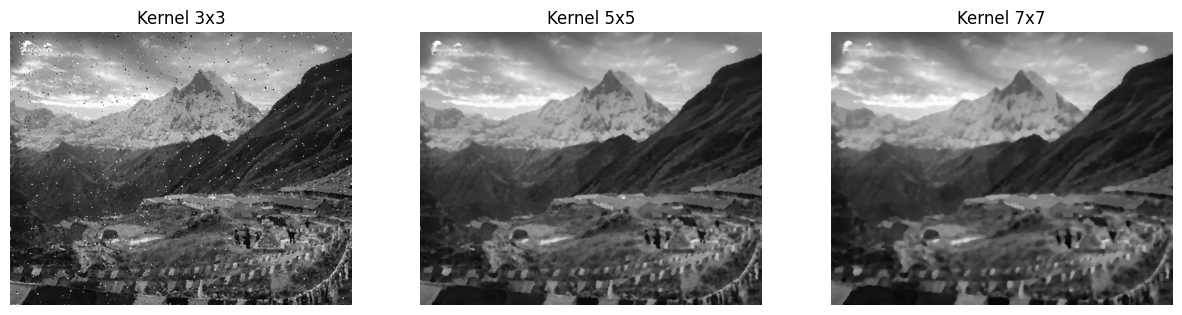

In [8]:
k3 = median_filter(noisy_image, 3, 1)
k5 = median_filter(noisy_image, 5, 1)
k7 = median_filter(noisy_image, 7, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(k3, cmap="gray")
plt.title("Kernel 3x3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(k5, cmap="gray")
plt.title("Kernel 5x5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(k7, cmap="gray")
plt.title("Kernel 7x7")
plt.axis("off")

plt.show()

Stride 1 Shape: (495, 619)
Stride 2 Shape: (248, 310)
Stride 3 Shape: (165, 207)


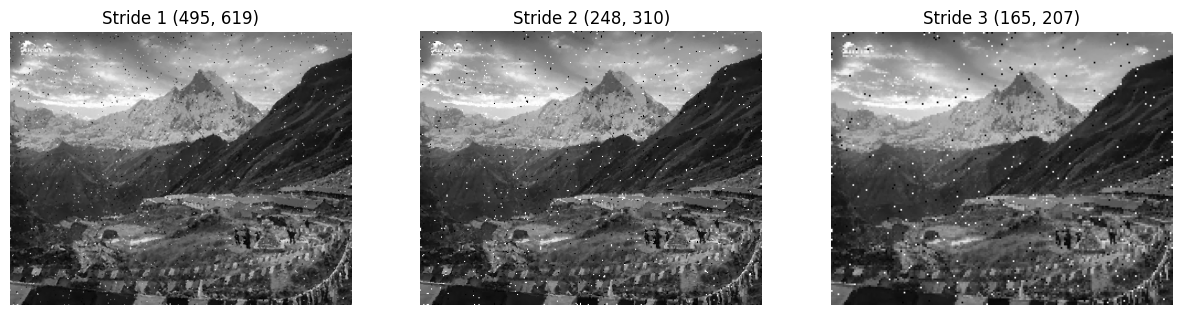

In [9]:
s1 = median_filter(noisy_image, 3, 1)
s2 = median_filter(noisy_image, 3, 2)
s3 = median_filter(noisy_image, 3, 3)

print("Stride 1 Shape:", s1.shape)
print("Stride 2 Shape:", s2.shape)
print("Stride 3 Shape:", s3.shape)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(s1, cmap="gray")
plt.title(f"Stride 1 {s1.shape}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(s2, cmap="gray")
plt.title(f"Stride 2 {s2.shape}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(s3, cmap="gray")
plt.title(f"Stride 3 {s3.shape}")
plt.axis("off")

plt.show()